✅ Files loaded successfully!

Movies Data Preview:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy   

Ratings Data Preview:
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858
Number of Movies: 87585
Number of Users: 200948


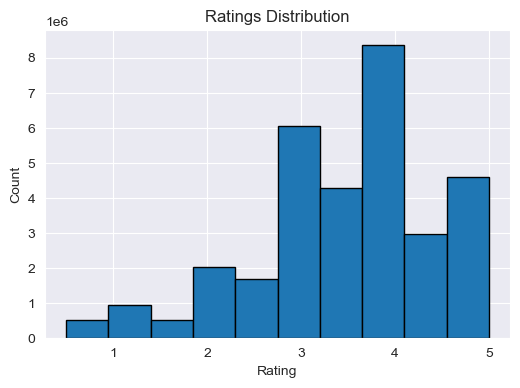


🎥 Top 10 recommendations for 'Toy Story (1995)':
1. Toy Story (1995)
2. Emperor's New Groove, The (2000)
3. My Little Pony: A New Generation (2021)
4. Adventures of Rocky and Bullwinkle, The (2000)
5. Luca (2021)
6. UglyDolls (2019)
7. Monsters, Inc. (2001)
8. The Magic Crystal (2011)
9. Toy Story Toons: Small Fry (2011)
10. Toy Story Toons: Hawaiian Vacation (2011)


In [1]:


# 2. Import Libraries

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import os


# 3. File Check & Load (User MUST have files locally)


# Files must be in the same folder as this notebook
movies_path = "movies.csv"
ratings_path = "ratings.csv"

# Check existence before reading
if not os.path.exists(movies_path) or not os.path.exists(ratings_path):
    raise FileNotFoundError("❌ Please place 'movies.csv' and 'ratings.csv' in the same directory as this script!")

# Load data
movies = pd.read_csv(movies_path)
ratings = pd.read_csv(ratings_path)

print("✅ Files loaded successfully!\n")
print("Movies Data Preview:")
print(movies.head(), "\n")
print("Ratings Data Preview:")
print(ratings.head())


# 4. Data Cleaning & Exploration

movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)
movies.dropna(inplace=True)
ratings.dropna(inplace=True)

print("Number of Movies:", movies['movieId'].nunique())
print("Number of Users:", ratings['userId'].nunique())

# Plot ratings distribution
plt.figure(figsize=(6,4))
ratings['rating'].hist(bins=10, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Ratings Distribution')
plt.show()


# 5. Feature Preparation (Using Genres)


movies['combined_features'] = movies['genres'].replace('(no genres listed)', '')

# TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['combined_features'])


# 6. Recommendation Function (Memory Efficient)


def get_recommendations(title, top_n=10):
    """
    Returns top N movie recommendations based on genre similarity.
    """
    results = movies[movies['title'].str.lower() == title.lower()]
    if results.empty:
        print(f"❌ Movie '{title}' not found in dataset.")
        return []

    idx = results.index[0]

    # Compute similarity only for this movie (not entire matrix)
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # Get indices of top N similar movies (excluding the movie itself)
    sim_indices = sim_scores.argsort()[-top_n-1:-1][::-1]

    return movies['title'].iloc[sim_indices]


# 7. Example Usage


print("\n🎥 Top 10 recommendations for 'Toy Story (1995)':")
recommendations = get_recommendations('Toy Story (1995)', top_n=10)

for i, title in enumerate(recommendations, 1):
    print(f"{i}. {title}")
